# Setting up

In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.1 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn

In [ ]:
pip install -U keras

In [ ]:
!pip install --upgrade tensorflow

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
!pip install utils
!pip install performer-pytorch
!pip install timm
!pip install -U tensorflow-addons
!pip install transformer-utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=1026882b38dd86d46f344cf73e48d25a528a2fadffa1cf2592e87b3965c62bf0
  Stored in directory: /root/.cache/pip/wheels/15/0c/b3/674aea8c5d91c642c817d4d630bd58faa316724b136844094d
Successfully built utils
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Adjust if needed (e.g., "0,1" for multiple GPUs)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Verify GPU is available
gpus = tf.config.experimental.list_physical_devices("GPU")
print("Num GPUs Available:", len(gpus))

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevents memory issues
        print("Using GPU:", gpus[0])
    except RuntimeError as e:
        print(e)  # GPU settings must be done before TensorFlow initialization

import utils
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
tf.compat.v1.set_random_seed(2019)
import torch
from torch import optim, nn
from torchvision import models, transforms
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
#import tensorflow_addons as tf
from keras.layers import Conv2D, ZeroPadding2D, Activation, Input, concatenate
from keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import AveragePooling2D,MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.layers import Lambda, Flatten, Dense, Dropout
import pandas as pd
from tensorflow.python.ops.numpy_ops import np_config
import numpy as np
from tensorflow.keras.preprocessing import sequence
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import matthews_corrcoef
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

Num GPUs Available: 1
Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Adjust if needed (e.g., "0,1" for multiple GPUs)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Verify GPU is available
gpus = tf.config.experimental.list_physical_devices("GPU")
print("Num GPUs Available:", len(gpus))

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevents memory issues
        print("Using GPU:", gpus[0])
    except RuntimeError as e:
        print(e)  # GPU settings must be done before TensorFlow initialization


Num GPUs Available: 1
Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("GPU Available:", tf.test.is_gpu_available())
print("GPU Name:", tf.config.experimental.list_physical_devices("GPU"))


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU Available: True
GPU Name: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# npy MERGE

In [ ]:
import numpy as np
import pandas as pd

data1 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/deletion_1.npy',allow_pickle=True)
data2 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/deletion_2.npy',allow_pickle=True)
data3 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/deletion_3.npy',allow_pickle=True)
data4 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/deletion_4.npy',allow_pickle=True)

data5 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/duplication_1.npy',allow_pickle=True)
data6 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/duplication_2.npy',allow_pickle=True)
data7 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/duplication_3.npy',allow_pickle=True)
data8 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/duplication_4.npy',allow_pickle=True)

data9 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/nocall_1.npy',allow_pickle=True)
data10 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/nocall_2.npy',allow_pickle=True)
data11 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/nocall_3.npy',allow_pickle=True)
data12 = np.load('/content/drive/MyDrive/OUTPUT/CNV_data/nocall_4.npy',allow_pickle=True)

In [ ]:
data1 = np.load('/content/drive/MyDrive/OUTPUT/deletion30Test.npy',allow_pickle=True)
data2 = np.load('/content/drive/MyDrive/OUTPUT/duplication30Test.npy',allow_pickle=True)
data3 = np.load('/content/drive/MyDrive/OUTPUT/nocall30Test.npy',allow_pickle=True)

In [ ]:
import numpy as np
import pandas as pd

# Create a list of the loaded arrays (assuming they are named sequentially as data1, data2, ..., data122)
data_list = [globals()[f"data{i}"] for i in range(1, 3)]  # Dynamically access variables data1, data2, ..., data122

# Convert each NumPy array to a DataFrame
deletion = [pd.DataFrame(data) for data in data_list]

# Concatenate all DataFrames into one
deletion = pd.concat(deletion, axis=0, ignore_index=True)

# Display the resulting DataFrame
print(deletion)

       0     1     2     3     4     5     6     7     8     9     ...  995   \
0      -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   2.0   
1      -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  60.0   
2      -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  82.0   
3      -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   1.0   
4      -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  91.0   
...     ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
17105  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  19.0   
17106  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  50.0   
17107  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   1.0   
17108  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   2.0   
17109  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...  20.0   

       996   997   998   999   1000  10

In [ ]:
import numpy as np
import pandas as pd

# Create a list of the loaded arrays (assuming they are named sequentially as data1, data2, ..., data122)
data_list = [globals()[f"data{i}"] for i in range(5,8)]  # Dynamically access variables data1, data2, ..., data122

# Convert each NumPy array to a DataFrame
duplication = [pd.DataFrame(data) for data in data_list]

# Concatenate all DataFrames into one
duplication = pd.concat(duplication, axis=0, ignore_index=True)

# Display the resulting DataFrame
print(duplication)

In [ ]:
import numpy as np
import pandas as pd

# Create a list of the loaded arrays (assuming they are named sequentially as data1, data2, ..., data122)
data_list = [globals()[f"data{i}"] for i in range(9,12)]  # Dynamically access variables data1, data2, ..., data122

# Convert each NumPy array to a DataFrame
nocall = [pd.DataFrame(data) for data in data_list]

# Concatenate all DataFrames into one
nocall = pd.concat(nocall, axis=0, ignore_index=True)

# Display the resulting DataFrame
print(nocall)

        0     1     2     3     4     5     6     7     8     9     ...  \
0       -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
1       -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
2       -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
3       -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
4       -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
...      ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
129995  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
129996  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
129997  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
129998  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   
129999  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  -1.0  ...   

         995    996    997    998    999   1000  1001         1002  \
0       114.0  113.0  109.0  

In [ ]:
data1=pd.DataFrame(data1)
data1['label'] = 1


In [ ]:
data2=pd.DataFrame(data2)
data2['label'] = 2

In [ ]:
data3=pd.DataFrame(data3)
data3['label'] = 0

In [ ]:
merged_df = pd.concat([data1,data2,data3])
merged_df

,0,1,2,3,4,5,6,7,8,9,...,996,997,998,999,1000,1001,1002,1003,1004,label
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,90190640.0,90190392.0,2.0,1
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,2.0,2.0,0.0,0.0,8013001.0,8012762.0,8.0,1
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,48.0,46.0,44.0,42.0,0.0,0.0,73541712.0,73541472.0,14.0,1
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,12811777.0,12811637.0,23.0,1
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,327.0,324.0,316.0,314.0,0.0,0.0,74885200.0,74884960.0,7.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,51.0,48.0,44.0,44.0,0.0,0.0,79983984.0,79983864.0,4.0,0
49996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,79.0,78.0,77.0,74.0,0.0,0.0,46058672.0,46058432.0,4.0,0
49997,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,66.0,66.0,66.0,64.0,0.0,0.0,4490614.0,4490495.0,12.0,0
49998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,39.0,39.0,38.0,38.0,0.0,0.0,55391968.0,55391732.0,7.0,0


In [ ]:
merged_df.to_csv('/content/drive/MyDrive/OUTPUT/data_all.csv')

# Data

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/OUTPUT/CNV_data/data_all.csv', index_col=0)


In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,...,996,997,998,999,1000,1001,1002,1003,1004,label
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,86.0,81.0,77.0,82.0,0.0,0.0,10263342.0,10263103.0,5.0,1
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,89.0,88.0,84.0,82.0,0.0,0.0,19394544.0,19394276.0,22.0,1
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,31.0,30.0,28.0,28.0,0.0,0.0,99390020.0,99389870.0,7.0,1
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,45.0,41.0,40.0,38.0,0.0,0.0,18343398.0,18343248.0,16.0,1
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,404.0,396.0,392.0,383.0,0.0,0.0,26735338.0,26735220.0,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,44.0,44.0,43.0,43.0,0.0,0.0,29516250.0,29516132.0,13.0,0
9996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,128.0,130.0,132.0,131.0,0.0,0.0,58257856.0,58257704.0,14.0,0
9997,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,41.0,39.0,41.0,41.0,0.0,0.0,105263400.0,105263280.0,10.0,0
9998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,163.0,161.0,154.0,152.0,0.0,0.0,20013656.0,20013536.0,24.0,0


In [ ]:
trainImages = np.load('/home/maryem/Desktop/New_folder/1000genomes_training_dataset/NA/nocall.npy')
print("Loaded dataset shape:", trainImages.shape)

# If needed, load sample names
with open('/home/maryem/Desktop/New_folder/1000genomes_training_dataset/NA/sample_names.txt', 'r') as f:
    sample_names = [line.strip() for line in f]
print("First few sample names:", sample_names[:5])

In [ ]:
data = np.load("/content/drive/MyDrive/OUTPUT/CNV_data/nocall.npz")
print(data.files)  # Lists all arrays stored in the file


['trainImages', 'sample_ids']


In [ ]:
import numpy as np

# Define file paths
file_paths = {
    "nocall": "/content/drive/MyDrive/OUTPUT/CNV_data/nocall.npz",
    "duplication": "/content/drive/MyDrive/OUTPUT/CNV_data/duplication.npz",
    "deletion": "/content/drive/MyDrive/OUTPUT/CNV_data/deletion.npz"
}

# Initialize lists to store data
train_images = []
sample_ids = []
labels = []  # Class labels: nocall=0, duplication=2, deletion=1

# Mapping of label names to their respective integers
label_mapping = {
    "nocall": 0,
    "duplication": 2,
    "deletion": 1
}

# Load each dataset and append data
for label_name, path in file_paths.items():
    data = np.load(path, allow_pickle=True)
    print(f"Keys in {path}: {data.files}")  # Debug: Print available keys

    img_data = data["trainImages"]

    # Ensure consistent shape (convert all to 2D: (N, F))
    if img_data.ndim == 3:  # If (N, 1, F), squeeze extra dimension
        img_data = np.squeeze(img_data, axis=1)

    train_images.append(img_data)  # Append modified images

    # Handling sample IDs
    if "sample_ids" in data:
        sample_ids.append(data["sample_ids"])
    elif "sample_names" in data:
        sample_ids.append(data["sample_names"])
    else:
        sample_ids.append(np.array([f"sample_{i}" for i in range(len(img_data))]))  # Dummy IDs

    # Assign class labels based on the `label_mapping`
    label = label_mapping[label_name]  # Get the label corresponding to the dataset name
    labels.extend([label] * len(img_data))  # Assign class labels

# Convert lists to numpy arrays
train_images = np.concatenate(train_images, axis=0)  # Now all have the same shape
sample_ids = np.concatenate(sample_ids, axis=0, dtype=object)  # Ensure text IDs
labels = np.array(labels)

# Print dataset information
print("Final dataset shape:", train_images.shape)  # Expected: (Total_Samples, Features)
print("Total samples:", len(sample_ids))
print("First few sample IDs:", sample_ids[:5])
print("First few labels:", labels[:5])


Keys in /content/drive/MyDrive/OUTPUT/CNV_data/nocall.npz: ['trainImages', 'sample_ids']
Keys in /content/drive/MyDrive/OUTPUT/CNV_data/duplication.npz: ['trainImages', 'sample_names']
Keys in /content/drive/MyDrive/OUTPUT/CNV_data/deletion.npz: ['trainImages', 'sample_names']
Final dataset shape: (6368, 1005)
Total samples: 6368
First few sample IDs: ['NA12878BGI500_datapoint_172392' 'NA12878NOVA6000_datapoint_71497'
 'NA12878NOVA6000_datapoint_142951' 'NA12878MGI2000_datapoint_101097'
 'NA12878HISEQ4000_datapoint_50404']
First few labels: [0 0 0 0 0]


In [ ]:
import numpy as np

# Define the mapping of prefixes to their numeric annotation
id_mapping = {
    "NA19239": 1,
    "HG00732": 2,
    "NA19240": 3
    }

# Your sample_ids array (flattened version)
sample_ids = sample_ids

# Flatten the array to 1D
sample_ids_flat = sample_ids.flatten()

# Convert sample IDs by replacing prefixes
short_ids = np.array([
    id_mapping.get(id.split('_')[0], -1)  # Use -1 for unknown prefixes
    for id in sample_ids_flat  # Iterate over the flattened array
])

# Print result
print(short_ids)


[-1 -1 -1 ... -1 -1 -1]


In [ ]:
import numpy as np

# Define the mapping of prefixes to their numeric annotation
id_mapping = {
    "NA12878BGI500": 1,
    "NA12878NOVA6000": 2,
    "NA12878HISEQ4000": 3,
    "NA12878MGI2000": 4
}

# Your sample_ids array (flattened version)
sample_ids = sample_ids
-Ouhmouk-phd
Ouvrir

# Flatten the array to 1D
sample_ids_flat = sample_ids.flatten()

# Convert sample IDs by replacing prefixes
short_ids = np.array([
    id_mapping.get(id.split('_')[0], -1)  # Use -1 for unknown prefixes
    for id in sample_ids_flat  # Iterate over the flattened array
])

# Print result
print(short_ids)

In [ ]:
import numpy as np

# Define the mapping of prefixes to their numeric annotation
id_mapping = {
    "HG00233": 1,
    "HG00235": 2,
    "HG00240": 3,
    "HG00258": 4,
    "HG00262": 5,
    "HG00264": 6,
    "HG00267": 7,
    "HG00269": 8,
    "HG00273": 9,
    "HG00284": 10,
    "HG00285": 11,
    "HG00311": 12,
    "HG00319": 13,
    "HG00335": 14,
    "HG00343": 15,
    "HG00366": 16,
    "HG00371": 17,
    "HG00380": 18,
    "HG00406": 19,
    "HG00451": 20,
    "HG00457": 21,
    "HG00458": 22,
    "HG00513": 23,
    "HG00524": 24,
    "HG00553": 25,
    "HG00556": 26,
    "HG00557": 27,#redo this redo this
    "HG00559": 28,
    "HG00565": 29,
    "HG02304": 30
}

# Your sample_ids array (flattened version)
sample_ids = sample_ids

# Flatten the array to 1D
sample_ids_flat = sample_ids.flatten()

# Convert sample IDs by replacing prefixes
short_ids = np.array([
    id_mapping.get(id.split('_')[0], -1)  # Use -1 for unknown prefixes
    for id in sample_ids_flat  # Iterate over the flattened array
])

# Print result
print(short_ids)

[14 17 23 ...  2  7 10]


In [ ]:
short_ids= np.array(short_ids)

In [ ]:
import numpy as np

# Reshape sample_ids and labels to be column vectors
sample_ids = np.array(short_ids, dtype=object).reshape(-1, 1)  # Shape: (N, 1)
labels = np.array(labels).reshape(-1, 1)  # Shape: (N, 1)

# Concatenate sample IDs, train images, and labels
merged_data = np.concatenate([sample_ids, train_images,labels ], axis=1)  # Shape: (N, F+2)

# Print merged dataset
print("Merged dataset shape:", merged_data.shape)
print("First row:", merged_data[0])

Merged dataset shape: (87095, 1007)
First row: [14 -1.0 -1.0 ... 140270240.0 2.0 0]


In [ ]:
data= pd.DataFrame(merged_data)
data = data.astype(int)

In [ ]:
import pandas as pd
import numpy as np

# Assuming 'data' is your DataFrame
# Convert columns to integers where appropriate
for column in data.columns:
    if data[column].dtype == float:
        data[column] = data[column].astype(int)

# Filter the DataFrame to keep only integer and float columns
data = data.select_dtypes(include=['int64', 'float64'])

# Display the modified DataFrame
print(data)

       0     1     2     3     4     5     6     7     8     9     ...  997   \
0        14    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...   122   
1        17    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...    35   
2        23    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...   302   
3         6    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...    22   
4        11    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...    14   
...     ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
87090    10    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...     9   
87091     7    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...     2   
87092     2    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...     1   
87093     7    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...    14   
87094    10    -1    -1    -1    -1    -1    -1    -1    -1    -1  ...     1   

       998   999   1000  1001  1002    

In [ ]:

#import pandas as pd
#import numpy as np

# Assuming 'data' is your DataFrame and '1004' is the relevant column with chromosome data
#breast_cancer_chromosomes = [10, 11, 13, 16, 17, 19, 22]  # Ensure these are integers

# Round the values in column "1004" to the nearest integer and convert them to integer type
#data["1004"] = np.round(data["1004"]).astype(int)

# Filter the DataFrame to keep only rows with the specified chromosomes
#data = data[data["1004"].isin(breast_cancer_chromosomes)]

# Ensure '1004' only contains the specified breast cancer chromosomes
# This step helps to prevent any unwanted values being added to the '1004' column later
#data["1004"] = data["1004"].astype(int)

# Display the filtered DataFrame
#print(data)
#data.shape


In [ ]:
data.shape

(37110, 1006)

In [ ]:
df = data.drop_duplicates()

In [ ]:
df.shape

(37109, 1006)

In [ ]:
df = pd.DataFrame(df)

In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,996,997,998,999,1000,1001,1002,1003,1004,label
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,2.0,2.0,2.0,2.0,0.0,0.0,916378.0,916229.0,12.0,1
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,60.0,61.0,59.0,58.0,0.0,0.0,40575610.0,40575370.0,19.0,1
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,82.0,79.0,79.0,79.0,0.0,0.0,10301644.0,10301495.0,8.0,1
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,7741163.0,7741095.0,8.0,1
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,90.0,88.0,87.0,88.0,0.0,0.0,19471424.0,19471304.0,22.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,73.0,73.0,71.0,72.0,0.0,0.0,100964960.0,100964840.0,2.0,0
19996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,106.0,106.0,103.0,100.0,0.0,0.0,113423530.0,113423290.0,9.0,0
19997,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,81.0,81.0,82.0,78.0,0.0,0.0,208437650.0,208437500.0,2.0,0
19998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,163.0,161.0,162.0,160.0,0.0,0.0,119804060.0,119803820.0,8.0,0


In [ ]:
data=df.drop([1005],axis=1)
y= df.iloc[:,-1]


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import TomekLinks
from sklearn import preprocessing
from sklearn import utils

#oversample = RandomOverSampler(sampling_strategy='not minority')
#X=df3.drop(df3.iloc[:, 3:4], axis=1)
#y=df3.iloc[:, 3:4]

#convert y values to categorical values
#lab = preprocessing.LabelEncoder()
#y_transformed = lab.fit_transform(y)



#oversample = SMOTE()
#X=np.array(z)
#y=np.array(y)
#data,y = oversample.fit_resample(X, y.ravel())


#X2=np.array(X2)
#y2=np.array(y2)
#X_over2, y_over2 = oversample.fit_resample(X2, y2.ravel())



#print(Counter(y))
z= df.drop(["label"],axis=1)
y= df.iloc[:,-1]

#Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(z, y)

data=X_resampled
y=y_resampled
data = data.astype(int)


In [ ]:
print(Counter(y_resampled))

Counter({1: 20000, 2: 20000, 0: 20000})


# Data processing

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,...,995,996,997,998,999,1000,1001,1002,1003,1004
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,2,2,2,2,2,0,0,916378,916229,12
1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,60,60,61,59,58,0,0,40575610,40575370,19
2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,82,82,79,79,79,0,0,10301644,10301495,8
3,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,1,1,1,1,1,0,0,7741163,7741095,8
4,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,91,90,88,87,88,0,0,19471424,19471304,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,210,208,205,200,198,0,0,131708971,131708851,6
59996,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,34,33,35,34,34,0,0,88912,88673,16
59997,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,142,143,142,141,139,0,0,68589460,68589338,11
59998,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,224,223,218,217,215,0,0,68575481,68575357,11


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Normalize depth values in columns from 0 to 1001
depth_columns = data.iloc[:, 0:1002]  # Assuming depth values are in columns 0 to 1001
depth_scaler = MinMaxScaler()
normalized_depth = depth_scaler.fit_transform(depth_columns)


In [ ]:
# Normalize the start and end positions
start_positions = data["1002"].values.reshape(-1, 1)
end_positions = data["1003"].values.reshape(-1, 1)

position_scaler = MinMaxScaler()
start_normalized = position_scaler.fit_transform(start_positions)
end_normalized = position_scaler.fit_transform(end_positions)

# Concatenate normalized start and end positions to the depth data for each row
# Here we repeat the values along the sequence length to match the depth dimensions
start_repeated = np.repeat(start_normalized, normalized_depth.shape[1], axis=1)
end_repeated = np.repeat(end_normalized, normalized_depth.shape[1], axis=1)

# Combine depth, start, and end as a 3D input tensor
combined_features = np.stack((normalized_depth, start_repeated, end_repeated), axis=2)  # Shape: (num_samples, 1002, 3)


In [ ]:
# Convert chromosome data to integers for embedding
# Convert the chromosome values to integers if they're not already
chr = np.round(data["1004"]).astype(int)  # Round to nearest integer and convert to int type
chromosome_labels, chromosome_indices = np.unique(chr, return_inverse=True)
chromosome_indices = chromosome_indices.reshape(-1, 1)  # Shape: (num_samples, 1)


In [ ]:
print(chr.unique())

[ 2 10  1 13 22  4 11 17  7 20 12 19  5  9  3 14 16 18 15  6 24  8 21 23]


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize the OneHotEncoder with updated parameter
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the chromosome indices
chromosome_one_hot = one_hot_encoder.fit_transform(chromosome_indices)

# Check the result
print("Shape of one-hot encoded chromosomes:", chromosome_one_hot.shape)
print("First few rows of one-hot encoded chromosomes:\n", chromosome_one_hot[:5])

Shape of one-hot encoded chromosomes: (60000, 24)
First few rows of one-hot encoded chromosomes:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [ ]:
chromosome_one_hot.shape

(11269, 24)

In [ ]:
chromosome_indices.shape

(11269, 1)

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,...,995,996,997,998,999,1000,1001,1002,1003,1004
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,9.0,9.0,9.0,9.0,9.0,0.0,0.0,109689144.0,109689000.0,1.0
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,90086860.0,90086780.0,11.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,3.0,3.0,3.0,3.0,3.0,0.0,0.0,13639695.0,13639456.0,21.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,79.0,77.0,71.0,68.0,67.0,0.0,0.0,89100370.0,89100250.0,2.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,7972378.0,7972104.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,133121170.0,133120980.0,9.0
9996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,150.0,150.0,152.0,151.0,150.0,0.0,0.0,5387484.0,5387365.0,17.0
9997,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,48.0,44.0,43.0,43.0,43.0,0.0,0.0,127993370.0,127993096.0,2.0
9998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,71.0,71.0,69.0,67.0,66.0,0.0,0.0,54482236.0,54482116.0,14.0


# Split Data

In [ ]:

# Assuming y is your target variable
# Split combined_features and chromosome_indices into training and testing sets
x_train_depth, x_test_depth, x_train_chromosome, x_test_chromosome, y_train, y_test = train_test_split(
    combined_features, chromosome_one_hot, y, test_size=0.3, random_state=45, stratify=y)

In [ ]:
print(x_train_chromosome.shape)  # Ensure this has shape (batch_size, 7)
print(x_test_chromosome.shape)  # Same check for test data

(42000, 24)
(18000, 24)


# Statistical Testing

In [ ]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

# Example data: replace these with your actual metrics from the models
# Assume accuracy scores from cross-validation or test set for two models
baseline_accuracies = np.array([0.85, 0.87, 0.86, 0.84, 0.85])  # Baseline model
extraction_accuracies = np.array([0.83, 0.85, 0.84, 0.83, 0.84])  # Feature extraction model

# Paired t-test: assumes the differences follow a normal distribution
t_stat, p_value_ttest = ttest_rel(baseline_accuracies, extraction_accuracies)
print(f"Paired t-test: t-statistic = {t_stat:.4f}, p-value = {p_value_ttest:.4f}")

# Wilcoxon signed-rank test: non-parametric alternative
w_stat, p_value_wilcoxon = wilcoxon(baseline_accuracies, extraction_accuracies)
print(f"Wilcoxon signed-rank test: w-statistic = {w_stat:.4f}, p-value = {p_value_wilcoxon:.4f}")

# Interpret the results
alpha = 0.05  # significance level

if p_value_ttest < alpha:
    print("Paired t-test: Significant difference in performance between models.")
else:
    print("Paired t-test: No significant difference in performance between models.")

if p_value_wilcoxon < alpha:
    print("Wilcoxon signed-rank test: Significant difference in performance between models.")
else:
    print("Wilcoxon signed-rank test: No significant difference in performance between models.")


Paired t-test: t-statistic = 0.6667, p-value = 0.6257
Wilcoxon signed-rank test: w-statistic = 1.0000, p-value = 1.0000
Paired t-test: No significant difference in performance between models.
Wilcoxon signed-rank test: No significant difference in performance between models.


# Autoencoder

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Input, Concatenate, Layer, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the checkpoint path
checkpoint_path = "/content/drive/MyDrive/CNV_data/model_checkpoint_updated1.weights.h5"

# Create the ModelCheckpoint callback
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Custom layer to repeat chromosome input across the sequence length
class RepeatChromosome(Layer):
    def call(self, inputs):
        return tf.tile(tf.expand_dims(inputs, axis=1), [1, 1002, 1])  # Repeat along the sequence length

# Feature embedding for chromosomes
def chromosome_embedding(input_shape):
    inputs = Input(shape=(input_shape,), name="chromosome_input")
    x = Dense(24, activation='relu')(inputs)  # Learn embedding representation
    x = RepeatChromosome()(x)  # Repeat along sequence length
    embedding_model = Model(inputs, x, name="chromosome_embedding")
    return embedding_model

# Simplified encoder
def create_encoder(input_shape):
    inputs = Input(shape=input_shape, name="combined_input")

    # Combine convolution and pooling into fewer layers
    x = Conv1D(filters=32, kernel_size=5, strides=2, padding='same', activation='relu')(inputs)
    x = Conv1D(filters=64, kernel_size=3, strides=2, padding='same', activation='relu')(x)

    # Use GlobalAveragePooling directly for feature aggregation
    x = GlobalAveragePooling1D()(x)

    # Reduce the dense layer size
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)  # Regularization

    # Define the encoder model
    encoder = Model(inputs, x, name="simplified_encoder")
    return encoder

class CustomAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, units):
        super(CustomAttentionLayer, self).__init__()
        self.attention_dense = tf.keras.layers.Dense(units, activation="softmax")  # Match input dimension
        self.multiply = tf.keras.layers.Multiply()

    def call(self, encoded_features):
        # Compute attention scores
        attention_scores = self.attention_dense(encoded_features)  # Shape: (batch_size, input_dim)
        # Multiply features by attention scores
        weighted_features = tf.multiply(encoded_features, attention_scores)  # Element-wise multiplication
        return weighted_features


# Model inputs
depth_position_input = Input(shape=(1002, 3), name="depth_position_input")
chromosome_input = Input(shape=(24,), name="chromosome_input")  # Chromosome one-hot input

# Chromosome embedding
chromosome_embedded = chromosome_embedding(24)(chromosome_input)

# Combine depth-position data with chromosome embeddings
combined_input = Concatenate(axis=2)([depth_position_input, chromosome_embedded])
# Pass through encoder
encoder = create_encoder(input_shape=(1002, 27))  # 1002 positions with 27 features
encoded_features = encoder(combined_input)

# Weighted feature combination
weighted_features = CustomAttentionLayer(units=128)(encoded_features)  # Match encoder output size

# Classifier head
x = Dense(256, activation='relu')(weighted_features)
x = Dropout(0.3)(x)  # Regularization
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)  # Adjusted for 3-class classification

# Compile model
model = Model(inputs=[depth_position_input, chromosome_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'custom_attention_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ chromosome_input          │ (None, 24)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depth_position_input      │ (None, 1002, 3)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ chromosome_embedding      │ (None, 1002, 24)       │            600 │ chromosome_input[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 1002, 27)       │              0 │ depth_position_input[… │
│                           │                        │                │ chromosome_embedding[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ simplified_encoder        │ (None, 128)            │         18,880 │ concatenate[0][0]      │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ custom_attention_layer    │ (None, 128)            │         16,512 │ simplified_encoder[0]… │
│ (CustomAttentionLayer)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 256)            │         33,024 │ custom_attention_laye… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 256)            │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │         32,896 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 3)              │            387 │ dense_4[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 102,299 (399.61 KB)

 Trainable params: 102,299 (399.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Training with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
   [x_train_depth, x_train_chromosome], y_train,
    epochs=20,
    batch_size=128,  # Reduced batch size for better memory management and faster epochs
    validation_data=([x_test_depth, x_test_chromosome], y_test),
    callbacks=[early_stopping, checkpoint]
)

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

## TL


In [ ]:
model.load_weights(checkpoint_path)
for layer in encoder.layers:
    layer.trainable = False  # Freeze encoder weights
x = Dense(256, activation='relu')(weighted_features)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)
model = Model(inputs=[depth_position_input, chromosome_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),  # Lower LR for fine-tuning
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.load_weights(checkpoint_path)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf


# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define new checkpoint path
checkpoint_path_expert = "/content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5"

# Save only the best model weights
checkpoint_expert = ModelCheckpoint(
    filepath=checkpoint_path_expert,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,  # If you want to save full model, set to False
    verbose=1
)
with tf.device('/GPU:0'):
    history = model.fit(
    [x_train_depth, x_train_chromosome], y_train,
    epochs=200, batch_size=8,
    validation_data=([x_test_depth, x_test_chromosome], y_test),
    callbacks=[early_stopping, checkpoint_expert]
)


Epoch 1/200
5247/5250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5637 - loss: 1.0544
Epoch 1: val_loss improved from inf to 0.83165, saving model to /content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.5638 - loss: 1.0543 - val_accuracy: 0.6197 - val_loss: 0.8317
Epoch 2/200
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6385 - loss: 0.8036
Epoch 2: val_loss improved from 0.83165 to 0.77970, saving model to /content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.6385 - loss: 0.8036 - val_accuracy: 0.6513 - val_loss: 0.7797
Epoch 3/200
5245/5250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6638 - loss: 0.7597
Epoch 3: val_loss improved from 0.77970 to 0.74658, saving model to /content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step 

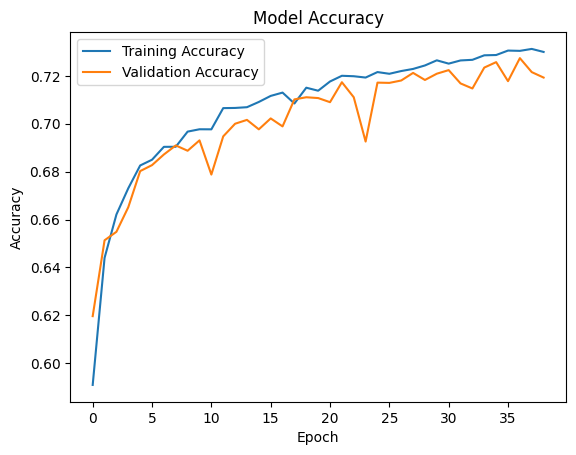

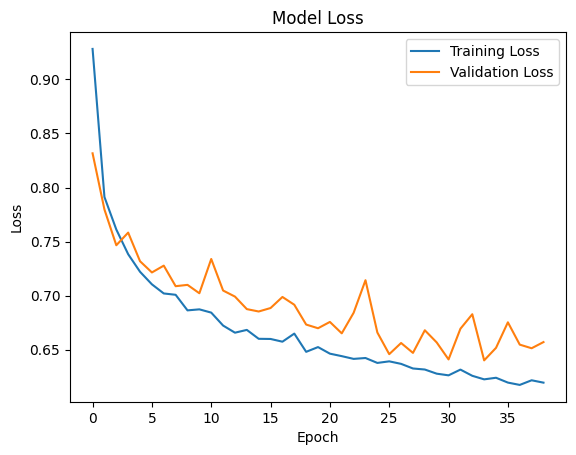

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate([x_test_depth, x_test_chromosome], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7211 - loss: 0.6417
Test Loss: 0.6401, Test Accuracy: 0.7234


563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Test Loss: 0.6401, Test Accuracy: 0.7234


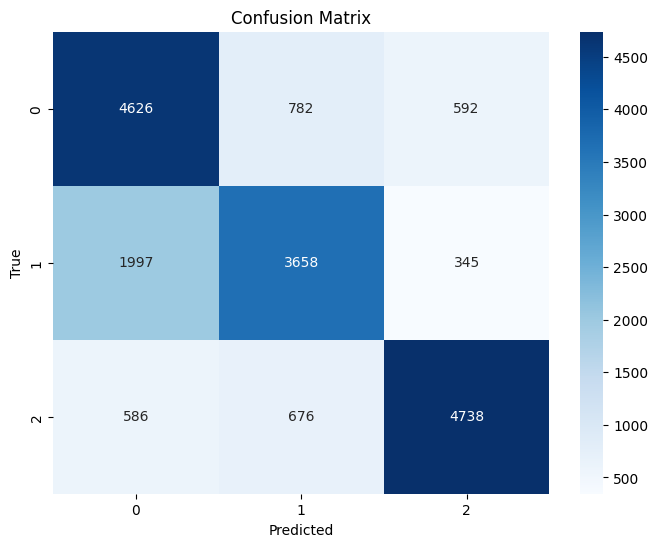

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.77      0.70      6000
           1       0.72      0.61      0.66      6000
           2       0.83      0.79      0.81      6000

    accuracy                           0.72     18000
   macro avg       0.73      0.72      0.72     18000
weighted avg       0.73      0.72      0.72     18000

Test AUC: 0.8845


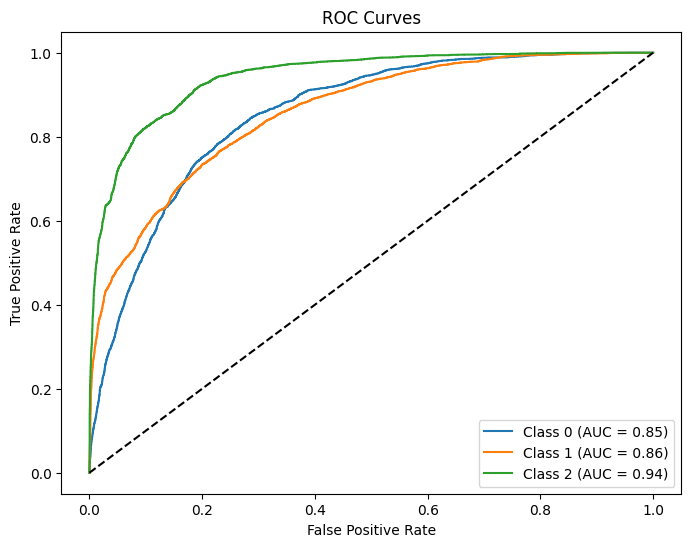

Total misclassified samples: 4978


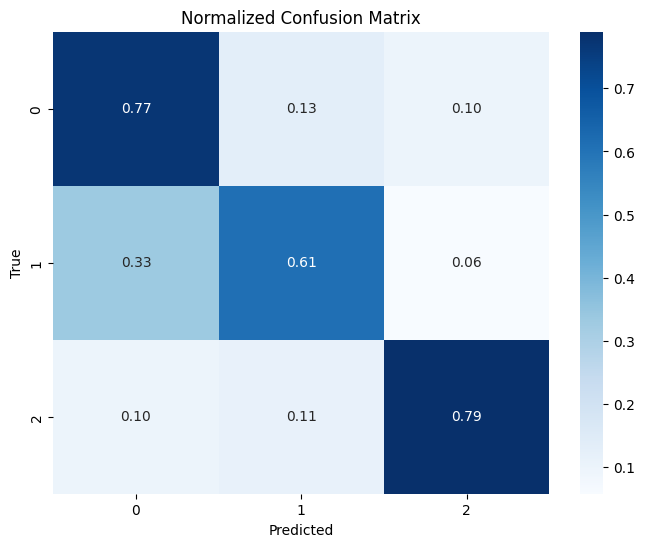

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])
#model.load_weights("/content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5")
# Define class labels
class_labels = ["0", "1", "2"]

# Get model predictions
predictions = model.predict([x_test_depth, x_test_chromosome])
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels

# Convert y_test to label format if one-hot encoded
y_test_labels = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Evaluate test accuracy and loss
test_loss, test_accuracy = model.evaluate([x_test_depth, x_test_chromosome], y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
report = classification_report(y_test_labels, predicted_labels, target_names=class_labels)
print("Classification Report:\n", report)

# Binarize labels for AUC calculation
y_test_binarized = label_binarize(y_test_labels, classes=range(3))

# Compute AUC for each class (One-vs-Rest)
test_auc = roc_auc_score(y_test_binarized, predictions, average="macro", multi_class="ovr")
print(f"Test AUC: {test_auc:.4f}")

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], predictions[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Count misclassified samples
misclassified_indices = np.where(y_test_labels != predicted_labels)[0]
#misclassified_counts = collections.Counter(y_test_labels[misclassified_indices])

print(f"Total misclassified samples: {len(misclassified_indices)}")
#print("Misclassification per class:", misclassified_counts)

# Normalized Confusion Matrix (Optional)
conf_matrix_normalized = conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()
#Test Loss: 0.5574, Test Accuracy: 0.7578

In [ ]:
#results_on_unseen data
test_loss, test_accuracy = model.evaluate([combined_features, chromosome_one_hot],  y)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7099 - loss: 0.7326
Test Loss: 0.8129, Test Accuracy: 0.6476


938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Test Loss: 0.8129, Test Accuracy: 0.6476


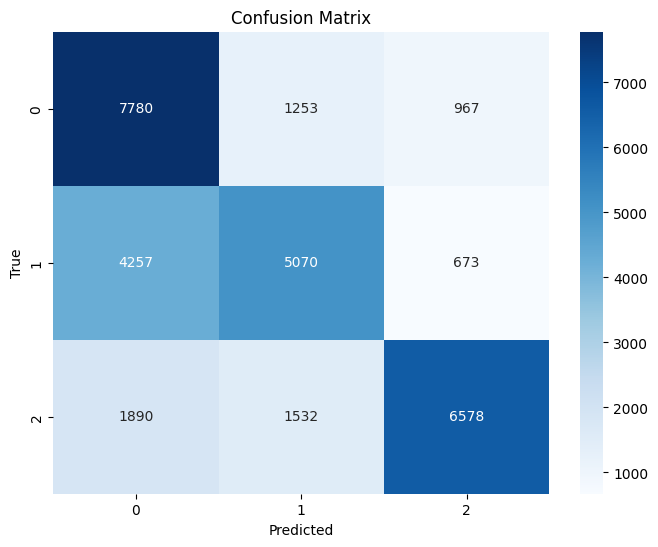

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.78      0.65     10000
           1       0.65      0.51      0.57     10000
           2       0.80      0.66      0.72     10000

    accuracy                           0.65     30000
   macro avg       0.67      0.65      0.65     30000
weighted avg       0.67      0.65      0.65     30000

Test AUC: 0.8211


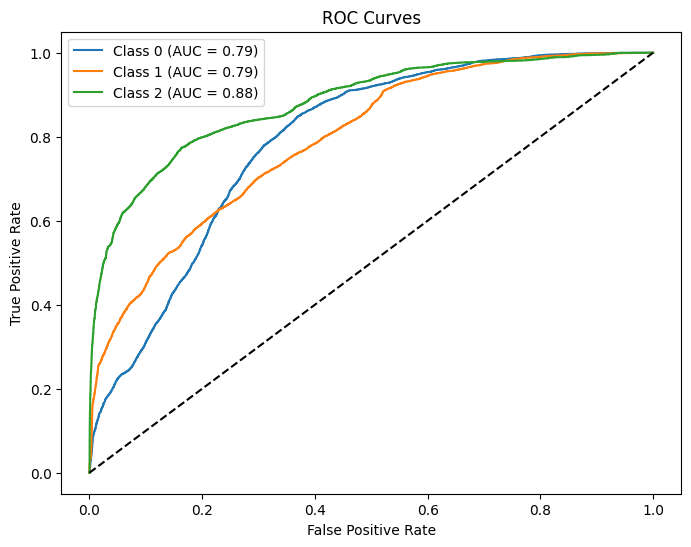

Total misclassified samples: 10572


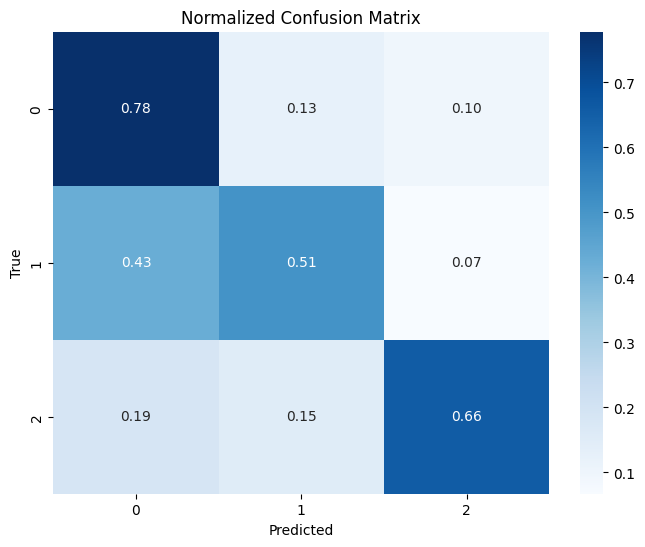

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])
model.load_weights("/content/drive/MyDrive/OUTPUT/CNV_data/model_checkpoint_expert_updated1.weights.h5")
# Define class labels
class_labels = ["0", "1", "2"]

# Get model predictions
predictions = model.predict([combined_features, chromosome_one_hot])
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels

# Convert y_test to label format if one-hot encoded
y_test_labels = np.argmax(y, axis=1) if y.ndim > 1 else y

# Evaluate test accuracy and loss
test_loss, test_accuracy = model.evaluate([combined_features, chromosome_one_hot], y, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
report = classification_report(y_test_labels, predicted_labels, target_names=class_labels)
print("Classification Report:\n", report)

# Binarize labels for AUC calculation
y_test_binarized = label_binarize(y_test_labels, classes=range(3))

# Compute AUC for each class (One-vs-Rest)
test_auc = roc_auc_score(y_test_binarized, predictions, average="macro", multi_class="ovr")
print(f"Test AUC: {test_auc:.4f}")

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], predictions[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Count misclassified samples
misclassified_indices = np.where(y_test_labels != predicted_labels)[0]
#misclassified_counts = collections.Counter(y_test_labels[misclassified_indices])

print(f"Total misclassified samples: {len(misclassified_indices)}")
#print("Misclassification per class:", misclassified_counts)

# Normalized Confusion Matrix (Optional)
conf_matrix_normalized = conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()
#Test Loss: 0.5574, Test Accuracy: 0.7578

## Evaluating Generalizability NA

In [ ]:
model.load_weights(checkpoint_path)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Load model weights
model.load_weights(checkpoint_path)


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Evaluate on test data on NA
results = model.evaluate([combined_features, chromosome_one_hot], y, verbose=1)

# Print metrics
print("Loss:", results[0])
print("Accuracy:", results[1])

2722/2722 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8521 - loss: 0.3283
Loss: 0.3742099106311798
Accuracy: 0.8391756415367126


2722/2722 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step


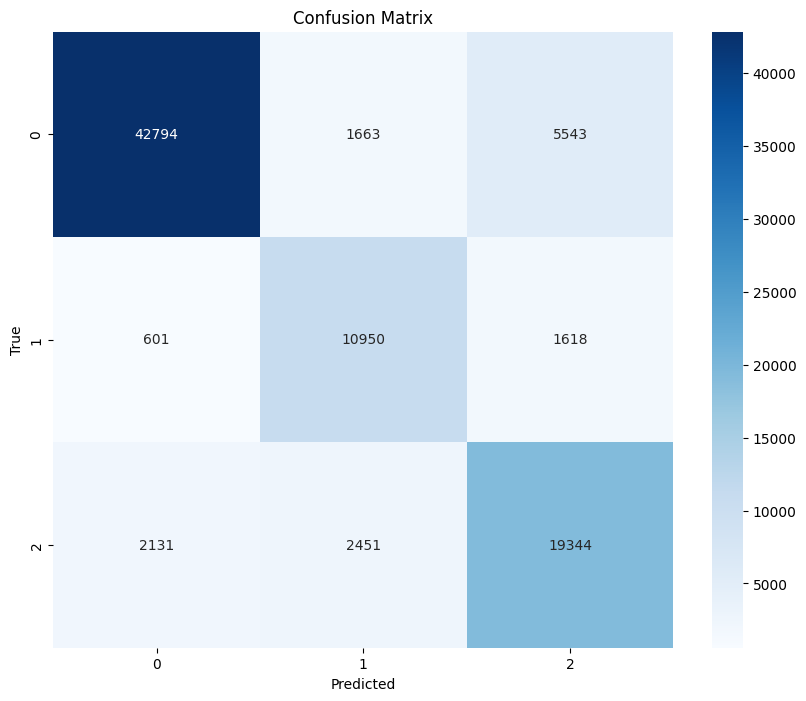

              precision    recall  f1-score   support

           0       0.94      0.86      0.90     50000
           1       0.73      0.83      0.78     13169
           2       0.73      0.81      0.77     23926

    accuracy                           0.84     87095
   macro avg       0.80      0.83      0.81     87095
weighted avg       0.85      0.84      0.84     87095

Test AUC: 0.9578


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

class_labels = ["0", "1", "2"]

# Get predictions for the test set
predictions = model.predict([combined_features, chromosome_one_hot])
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels if classification

# Confusion matrix
conf_matrix = confusion_matrix(y, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Generate classification report with string labels
report = classification_report(y, predicted_labels, target_names=class_labels)
print(report)

# Binarize the test labels (one-hot encoding)
y_test_binarized = label_binarize(y, classes=range(3))  # Adjust range to match your classes

# Compute AUC for each class and average (macro)
test_auc = roc_auc_score(y_test_binarized, predictions, average="macro", multi_class="ovr")
print(f"Test AUC: {test_auc:.4f}")

In [ ]:
combined_features_NA=combined_features
chromosome_one_hot_NA= chromosome_one_hot
y_NA=y
import numpy as np

# Save individual arrays
np.save("/content/drive/MyDrive/CNV_data/combined_features_NA.npy", combined_features)
np.save("/content/drive/MyDrive/CNV_data/chromosome_one_hot_NA.npy", chromosome_one_hot)
np.save("/content/drive/MyDrive/CNV_data/y_NA.npy", y)

In [ ]:
# Evaluate on test data on NA
results = model.evaluate([combined_features, chromosome_one_hot], y, verbose=1)

# Print metrics
print("Loss:", results[0])
print("Accuracy:", results[1])

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7950 - loss: 0.5003
Loss: 0.603843629360199
Accuracy: 0.75855553150177


In [ ]:
# Evaluate on test data on ch
results = model.evaluate([combined_features, chromosome_one_hot], y, verbose=1)

# Print metrics
print("Loss:", results[0])
print("Accuracy:", results[1])

282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7950 - loss: 0.5003
Loss: 0.6038435697555542
Accuracy: 0.75855553150177


282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


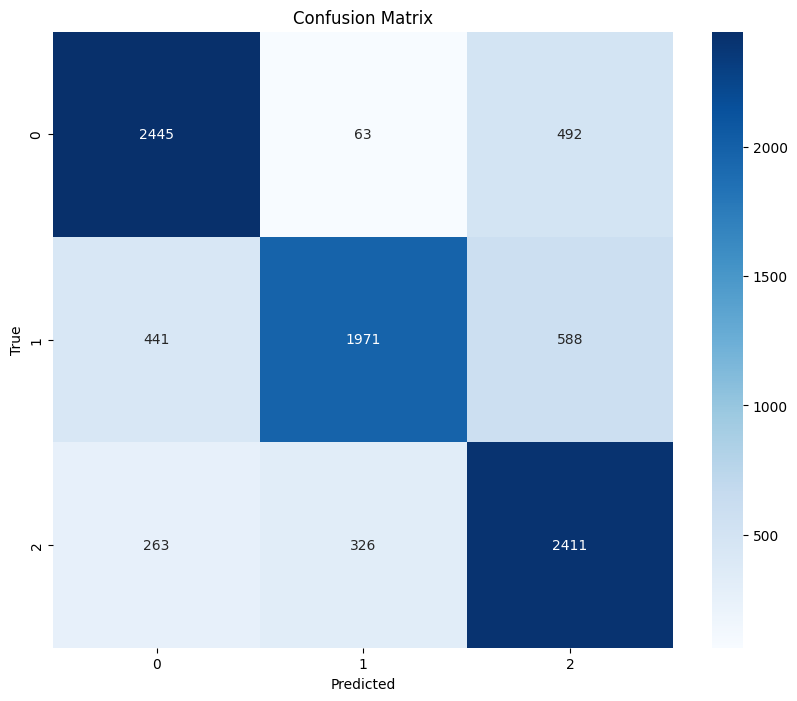

              precision    recall  f1-score   support

           0       0.78      0.81      0.80      3000
           1       0.84      0.66      0.74      3000
           2       0.69      0.80      0.74      3000

    accuracy                           0.76      9000
   macro avg       0.77      0.76      0.76      9000
weighted avg       0.77      0.76      0.76      9000

Test AUC: 0.9173


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

class_labels = ["0", "1", "2"]

# Get predictions for the test set
predictions = model.predict([combined_features, chromosome_one_hot])
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels if classification

# Confusion matrix
conf_matrix = confusion_matrix(y, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Generate classification report with string labels
report = classification_report(y, predicted_labels, target_names=class_labels)
print(report)

# Binarize the test labels (one-hot encoding)
y_test_binarized = label_binarize(y, classes=range(3))  # Adjust range to match your classes

# Compute AUC for each class and average (macro)
test_auc = roc_auc_score(y_test_binarized, predictions, average="macro", multi_class="ovr")
print(f"Test AUC: {test_auc:.4f}")


4795/4795 ━━━━━━━━━━━━━━━━━━━━ 54s 11ms/step


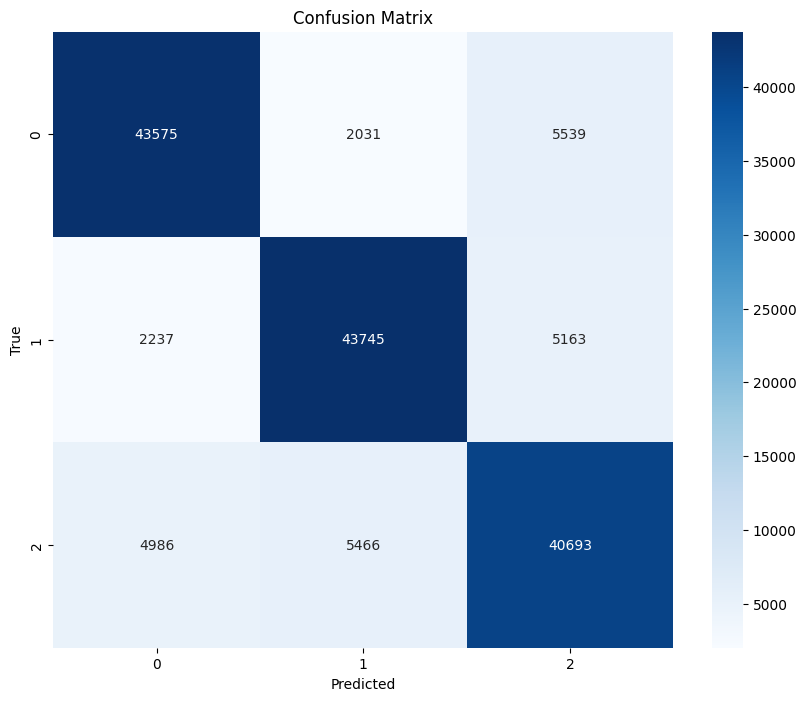

              precision    recall  f1-score   support

           0       0.86      0.85      0.85     51145
           1       0.85      0.86      0.85     51145
           2       0.79      0.80      0.79     51145

    accuracy                           0.83    153435
   macro avg       0.83      0.83      0.83    153435
weighted avg       0.83      0.83      0.83    153435

Test AUC: 0.9574


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
class_labels = ["0", "1", "2"]
# Get predictions for the test set
predictions = model.predict([x_test_depth, x_test_chromosome])
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels if classification

# Confusion matrix
conf_matrix = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Convert class_labels to strings
class_labels_str = [str(label) for label in class_labels]

# Generate classification report with string labels
report = classification_report(y_test, predicted_labels, target_names=class_labels_str)
print(report)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the test labels (one-hot encoding)
y_test_binarized = label_binarize(y_test, classes=range(3))  # Adjust range to match your classes

# Compute AUC for each class and average (macro)
test_auc = roc_auc_score(y_test_binarized, predictions, average="macro")
print(f"Test AUC: {test_auc:.4f}")

In [ ]:
from sklearn.metrics import average_precision_score

# Compute PR-AUC for each class
pr_aucs = [average_precision_score(y_test_binarized[:, i], predictions[:, i]) for i in range(3)]
mean_pr_auc = np.mean(pr_aucs)

print(f"Class 0 PR-AUC: {pr_aucs[0]:.4f}")
print(f"Class 1 PR-AUC: {pr_aucs[1]:.4f}")
print(f"Class 2 PR-AUC: {pr_aucs[2]:.4f}")
print(f"Mean PR-AUC: {mean_pr_auc:.4f}")


Class 0 PR-AUC: 0.9430
Class 1 PR-AUC: 0.9380
Class 2 PR-AUC: 0.8931
Mean PR-AUC: 0.9247


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predicted_labels, average=None)
recall = recall_score(y_test, predicted_labels, average=None)
f1 = f1_score(y_test, predicted_labels, average=None)

print(f"Precision per class: {precision}")
print(f"Recall per class: {recall}")
print(f"F1-Score per class: {f1}")


Precision per class: [0.85780936 0.85369424 0.79176963]
Recall per class: [0.85198944 0.85531332 0.79563985]
F1-Score per class: [0.8548895  0.85450301 0.79370002]


In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, predicted_labels)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, predicted_labels)
print(f"Cohen's Kappa Score: {kappa:.4f}")
from sklearn.metrics import log_loss

logloss = log_loss(y_test_binarized, predictions)
print(f"Log Loss: {logloss:.4f}")


Matthews Correlation Coefficient (MCC): 0.7515
Cohen's Kappa Score: 0.7515
Log Loss: 0.3908


In [ ]:
import numpy as np

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, predicted_labels)

# Compute sensitivity (recall) for each class
sensitivity_per_class = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)

# Compute specificity for each class
specificity_per_class = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)

# Print results
for i, (sensitivity, specificity) in enumerate(zip(sensitivity_per_class, specificity_per_class)):
    print(f"Class {i} - Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")


Class 0 - Sensitivity (Recall): 0.8520, Specificity: 0.8578
Class 1 - Sensitivity (Recall): 0.8553, Specificity: 0.8537
Class 2 - Sensitivity (Recall): 0.7956, Specificity: 0.7918


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, predicted_labels)
print(f"Balanced Accuracy: {balanced_acc:.4f}")


Balanced Accuracy: 0.8343


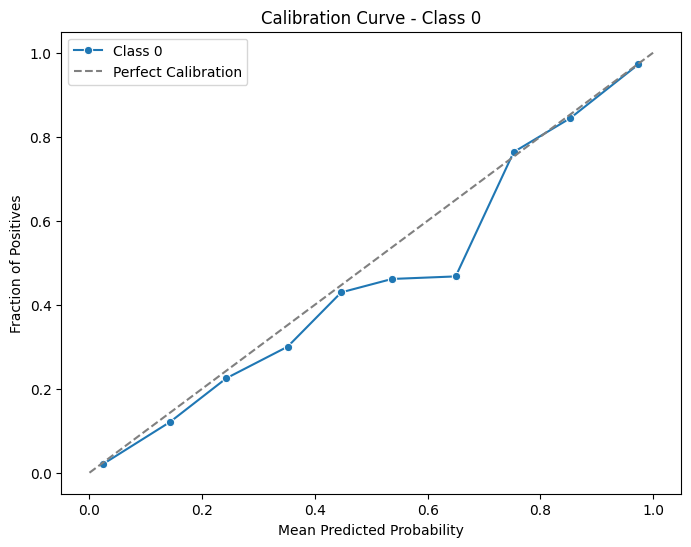

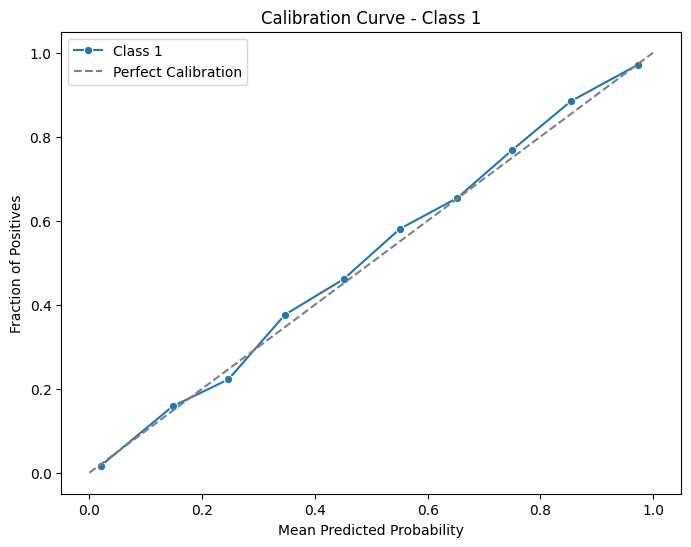

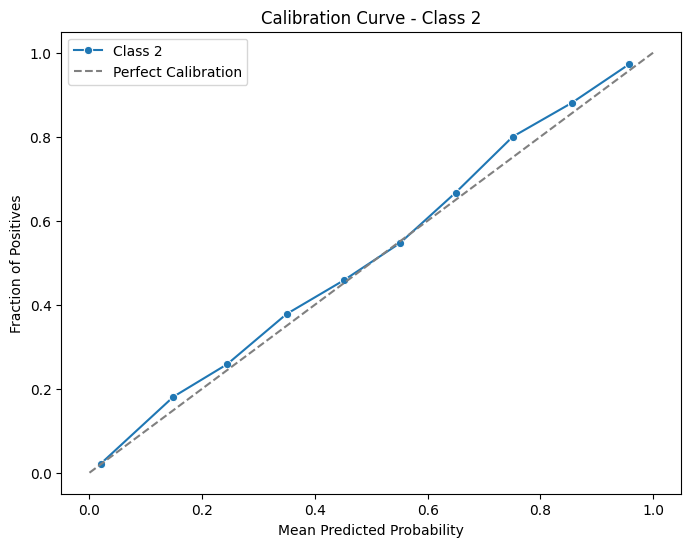

In [ ]:
import numpy as np
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming predictions and true labels are ready
y_prob = predictions  # Predicted probabilities from the model
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to 1D class labels

# For each class, plot calibration curves
for class_idx in range(y_prob.shape[1]):  # Loop over each class
    prob_class = y_prob[:, class_idx]  # Extract probabilities for the class
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true == class_idx, prob_class, n_bins=10
    )

    plt.figure(figsize=(8, 6))
    sns.lineplot(x=mean_predicted_value, y=fraction_of_positives, marker='o', label=f'Class {class_idx}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Curve - Class {class_idx}')
    plt.legend()
    plt.show()


In [ ]:
test_loss_full, test_accuracy_full = model.evaluate(
    [x_train_depth, x_train_chromosome], y_train)
print(f"Pretrained Full Pipeline - Test Loss: {test_loss_full}, Test Accuracy: {test_accuracy_full}")